In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense,Input

In [4]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 25000
Testing Samples : 25000


In [6]:
print(X_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [7]:
print(y_train[0])

1


In [8]:
#pad the sequence
max_length = 200
X_train = pad_sequences(X_train,maxlen=max_length,padding="post",truncating="post")

X_test = pad_sequences(X_test,maxlen=max_length,padding="post",truncating="post")

In [9]:
X_train.shape, X_test.shape

((25000, 200), (25000, 200))

In [10]:
# build the model
model = Sequential()
model.add(
    Input(shape=(200,))
)
model.add(Embedding(input_dim=vocab_size,output_dim=64,input_length=max_length,mask_zero=True))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
model.add(
    SimpleRNN(
        units=64,
        activation="tanh"
    )
)

In [12]:
model.add(
    Dense(
        32,
        activation="relu"
    )
)

model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,369 (2.48 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.5092 - loss: 0.6948 - val_accuracy: 0.5134 - val_loss: 0.6924
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5975 - loss: 0.6551 - val_accuracy: 0.7044 - val_loss: 0.5725
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7195 - loss: 0.5515 - val_accuracy: 0.7258 - val_loss: 0.5759
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7592 - loss: 0.4941 - val_accuracy: 0.6686 - val_loss: 0.6165
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8237 - loss: 0.3961 - val_accuracy: 0.7698 - val_loss: 0.5123
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7837 - loss: 0.4570 - val_accuracy: 0.6184 - val_loss: 0.6650
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7862 - loss: 0.4556 - val_accuracy: 0.5986 - val_loss: 0.6694
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7757 - loss: 0.4667 - val_ac

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7604 - loss: 0.5294
Test Loss : 0.5293759107589722
Test Accuracy : 0.7604399919509888


In [17]:
predictions = model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


In [18]:
print(predictions[:10])

[[0.03346388]
 [0.9515392 ]
 [0.8500879 ]
 [0.08228133]
 [0.93808854]
 [0.36905777]
 [0.50769776]
 [0.04269335]
 [0.533116  ]
 [0.9484806 ]]


In [19]:
predicted_class = (predictions > 0.5).astype(int)

In [20]:
for i in range(10):
    print(
        f"Actual : {y_test[i]}   Predicted : {predicted_class[i][0]}"
    )

Actual : 0   Predicted : 0
Actual : 1   Predicted : 1
Actual : 1   Predicted : 1
Actual : 0   Predicted : 0
Actual : 1   Predicted : 1
Actual : 1   Predicted : 0
Actual : 1   Predicted : 1
Actual : 0   Predicted : 0
Actual : 0   Predicted : 1
Actual : 1   Predicted : 1


In [21]:
from sklearn.metrics import classification_report,confusion_matrix

In [22]:
print(
    classification_report(
        y_test,
        predicted_class
    )
)

              precision    recall  f1-score   support

           0       0.76      0.76      0.76     12500
           1       0.76      0.76      0.76     12500

    accuracy                           0.76     25000
   macro avg       0.76      0.76      0.76     25000
weighted avg       0.76      0.76      0.76     25000



In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predicted_class
)

print(cm)

[[9533 2967]
 [3022 9478]]


<Figure size 600x600 with 0 Axes>

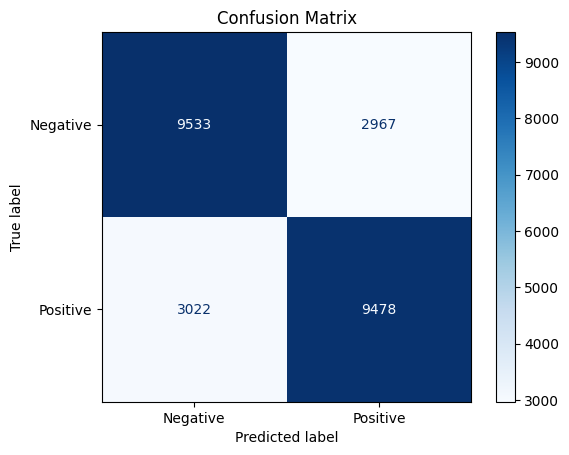

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.figure(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# **Model 1 (ANN Baseline)**

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

ann_model = Sequential()

ann_model.add(Input(shape=(max_length,)))

ann_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    )
)

ann_model.add(Flatten())

ann_model.add(Dense(64, activation="relu"))

ann_model.add(Dense(32, activation="relu"))

ann_model.add(Dense(1, activation="sigmoid"))

In [26]:
ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [27]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [28]:
history_ann = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7370 - loss: 0.4893 - val_accuracy: 0.8344 - val_loss: 0.3739
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9483 - loss: 0.1382 - val_accuracy: 0.8378 - val_loss: 0.4556
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9962 - loss: 0.0134 - val_accuracy: 0.8400 - val_loss: 0.6351
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9998 - loss: 0.0024 - val_accuracy: 0.8390 - val_loss: 0.6986


In [29]:
loss_ann, acc_ann = ann_model.evaluate(
    X_test,
    y_test
)

print("Loss :", loss_ann)
print("Accuracy :", acc_ann)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8242 - loss: 0.3924
Loss : 0.39243343472480774
Accuracy : 0.8242400288581848


In [30]:
predictions_ann = ann_model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [31]:
predicted_class_ann = (
    predictions_ann > 0.5
).astype(int)

In [32]:
print(
    classification_report(
        y_test,
        predicted_class_ann
    )
)

              precision    recall  f1-score   support

           0       0.84      0.80      0.82     12500
           1       0.81      0.85      0.83     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000



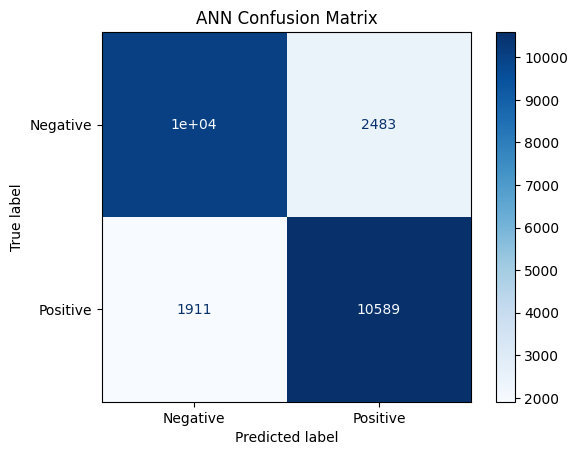

In [33]:
cm = confusion_matrix(
    y_test,
    predicted_class_ann
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative","Positive"]
)

disp.plot(cmap="Blues")

plt.title("ANN Confusion Matrix")

plt.show()

# **LSTM MODEL**

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [35]:
lstm_model = Sequential()

lstm_model.add(
    Input(shape=(max_length,))
)

lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        mask_zero=True
    )
)

lstm_model.add(
    LSTM(
        units=64
    )
)

lstm_model.add(
    Dense(
        32,
        activation="relu"
    )
)

lstm_model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

In [36]:
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [38]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

In [39]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7551 - loss: 0.4912 - val_accuracy: 0.8098 - val_loss: 0.4457
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8869 - loss: 0.2871 - val_accuracy: 0.8540 - val_loss: 0.3406
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9162 - loss: 0.2203 - val_accuracy: 0.8516 - val_loss: 0.3500
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9466 - loss: 0.1476 - val_accuracy: 0.8548 - val_loss: 0.4020
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9556 - loss: 0.1215 - val_accuracy: 0.8468 - val_loss: 0.5036
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9694 - loss: 0.0905 - val_accuracy: 0.8234 - val_loss: 0.5271
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9769 - loss: 0.0671 - val_accuracy: 0.8374 - val_loss: 0.6455
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9795 - loss: 0.0596 - val_accu

In [40]:
loss_lstm, acc_lstm = lstm_model.evaluate(
    X_test,
    y_test
)

print("Loss :", loss_lstm)
print("Accuracy :", acc_lstm)

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8425 - loss: 0.3600
Loss : 0.3600381314754486
Accuracy : 0.8424800038337708


In [41]:
predictions_lstm = lstm_model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step


In [42]:
predicted_class_lstm = (
    predictions_lstm > 0.5
).astype(int)

In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predicted_class_lstm
    )
)

              precision    recall  f1-score   support

           0       0.90      0.77      0.83     12500
           1       0.80      0.91      0.85     12500

    accuracy                           0.84     25000
   macro avg       0.85      0.84      0.84     25000
weighted avg       0.85      0.84      0.84     25000



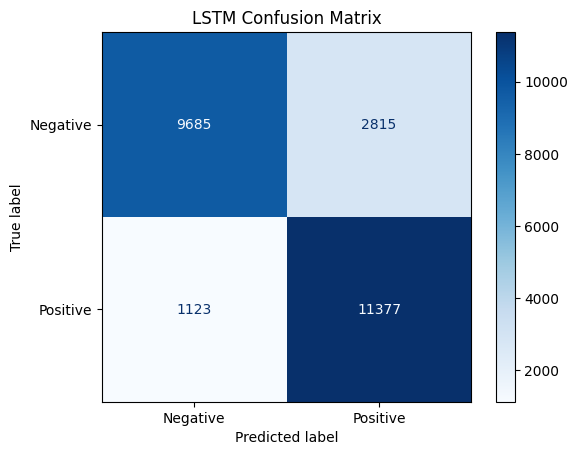

In [44]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    predicted_class_lstm
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative","Positive"]
)

disp.plot(cmap="Blues")

plt.title("LSTM Confusion Matrix")

plt.show()